DATASET INFORMATION
Number of Classes : 3
Class Names       : {0: 'helmet', 1: 'person', 2: 'vest'}

TRAIN DATASET ANALYSIS
Total Images           : 2991
Total Objects          : 16646
Missing Label Files    : 0
Empty Label Files      : 0
Average Objects/Image  : 5.57

Class Distribution:
helmet          : 6346
person          : 7083
vest            : 3217

VALIDATION DATASET ANALYSIS
Total Images           : 119
Total Objects          : 614
Missing Label Files    : 0
Empty Label Files      : 0
Average Objects/Image  : 5.16

Class Distribution:
person          : 241
vest            : 141
helmet          : 232

TEST DATASET ANALYSIS
Total Images           : 90
Total Objects          : 538
Missing Label Files    : 0
Empty Label Files      : 0
Average Objects/Image  : 5.98

Class Distribution:
helmet          : 195
person          : 214
vest            : 129

OVERALL CLASS DISTRIBUTION
    Class  Count
0  helmet   6773
1  person   7538
2    vest   3487

CSV File Saved Successfully!


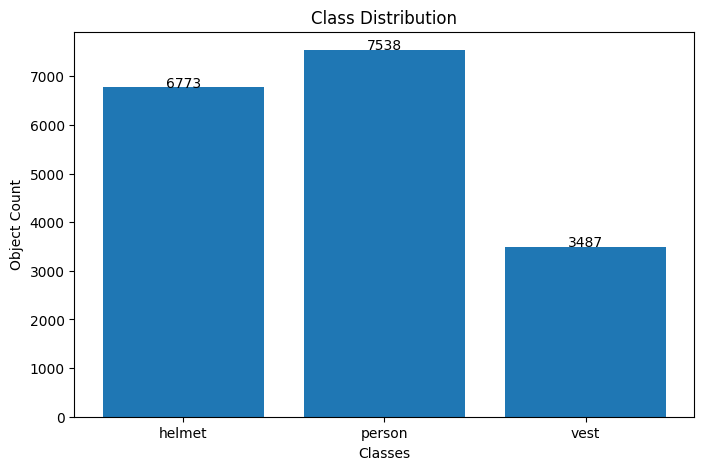

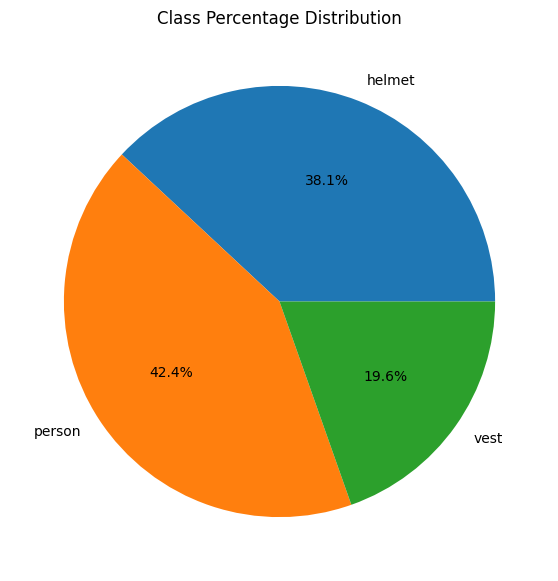

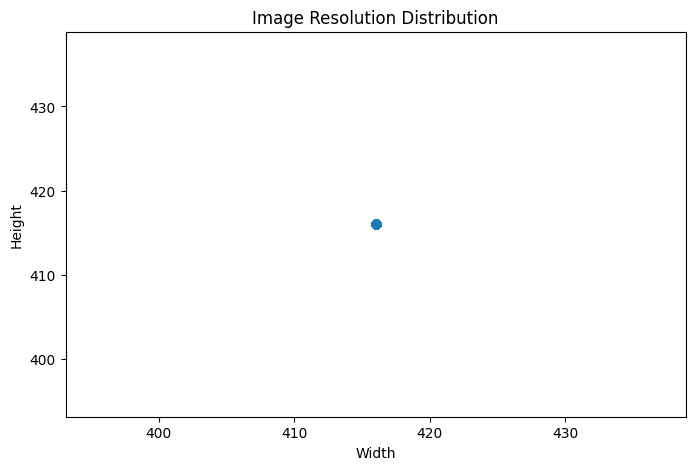

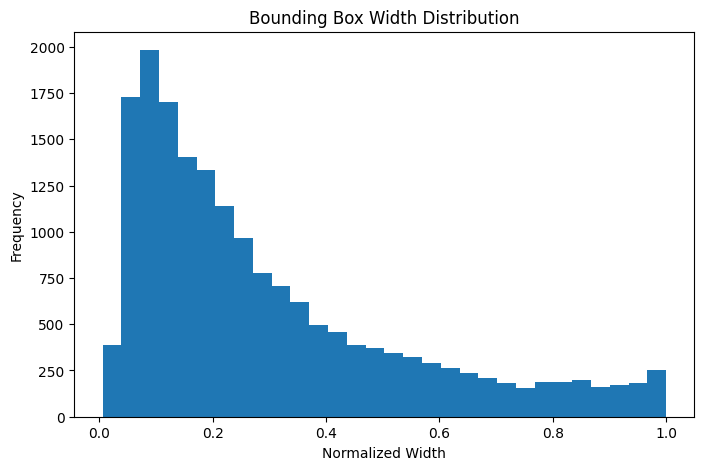

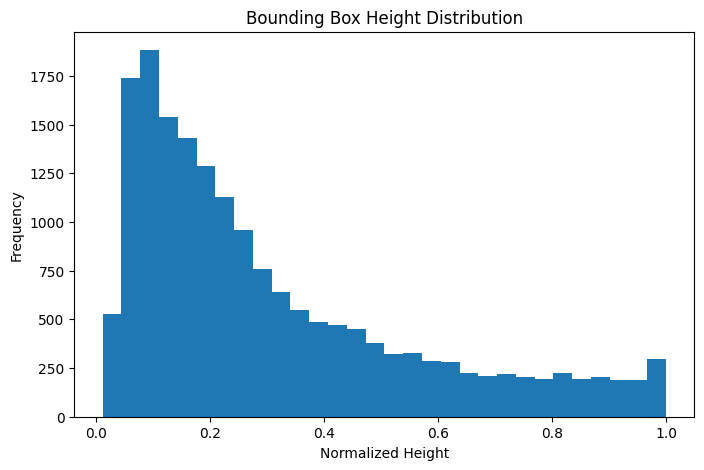

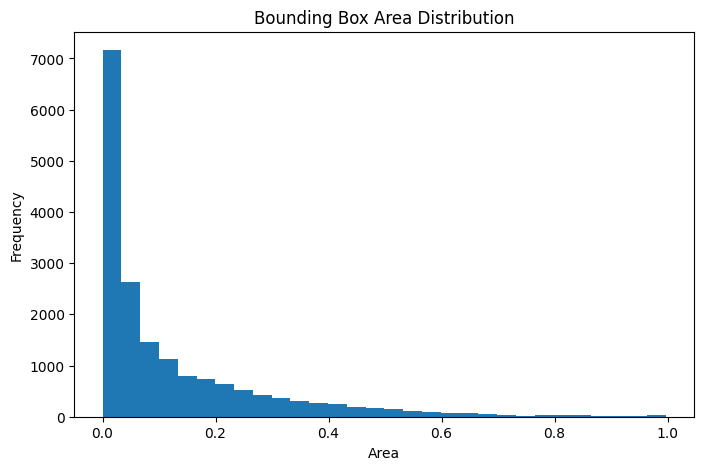

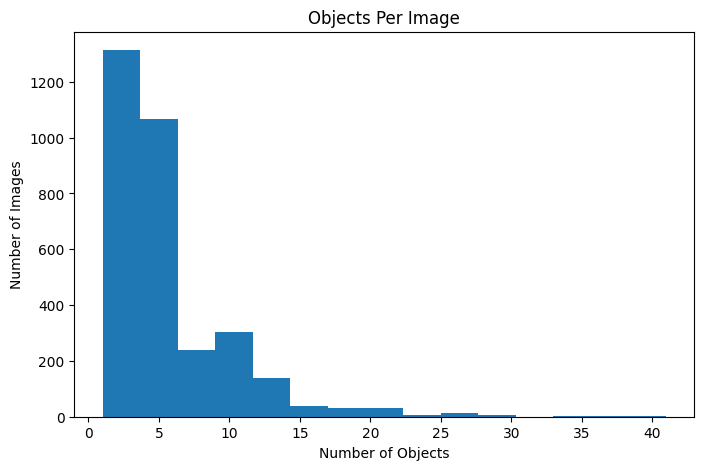


FINAL SUMMARY
Total Classes : 3
Classes       : ['helmet', 'person', 'vest']

Total Object Counts:
helmet          : 6773
person          : 7538
vest            : 3487

Analytics Completed Successfully!
Graphs Generated Successfully!
CSV Saved As: dataset_analytics.csv


In [2]:
# ============================================================
# FULL YOLO OBJECT DETECTION DATA ANALYTICS
# ============================================================

# Dataset Structure:
#
# ppe_filtered/
# ├── train/
# │   ├── images/
# │   └── labels/
# ├── valid/
# │   ├── images/
# │   └── labels/
# ├── test/
# │   ├── images/
# │   └── labels/
# └── data.yaml
#
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import os
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# =========================
# LOAD YAML FILE
# =========================

yaml_path = "ppe_filtered/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Number of Classes :", data["nc"])
print("Class Names       :", class_names)

# =========================
# DATASET ROOT
# =========================

dataset_root = "ppe_filtered"

# =========================
# PATHS
# =========================

train_images = os.path.join(dataset_root, "train", "images")
train_labels = os.path.join(dataset_root, "train", "labels")

valid_images = os.path.join(dataset_root, "valid", "images")
valid_labels = os.path.join(dataset_root, "valid", "labels")

test_images = os.path.join(dataset_root, "test", "images")
test_labels = os.path.join(dataset_root, "test", "labels")

# =========================
# ANALYSIS FUNCTION
# =========================

def analyze_dataset(image_dir, label_dir, split_name):

    image_files = [
        f for f in os.listdir(image_dir)
        if f.endswith((".jpg", ".jpeg", ".png"))
    ]

    total_images = len(image_files)

    class_counter = Counter()

    image_widths = []
    image_heights = []

    bbox_widths = []
    bbox_heights = []
    bbox_areas = []

    objects_per_image = []

    missing_labels = 0
    empty_labels = 0
    total_objects = 0

    for img_file in image_files:

        img_path = os.path.join(image_dir, img_file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w, _ = img.shape

        image_widths.append(w)
        image_heights.append(h)

        # Label file path
        label_file = img_file.rsplit(".", 1)[0] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        # Missing label
        if not os.path.exists(label_path):
            missing_labels += 1
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        # Empty label
        if len(lines) == 0:
            empty_labels += 1

        objects_per_image.append(len(lines))

        total_objects += len(lines)

        for line in lines:

            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])

            x_center = float(values[1])
            y_center = float(values[2])
            bbox_w = float(values[3])
            bbox_h = float(values[4])

            class_name = class_names[class_id]

            class_counter[class_name] += 1

            bbox_widths.append(bbox_w)
            bbox_heights.append(bbox_h)
            bbox_areas.append(bbox_w * bbox_h)

    # =========================
    # PRINT RESULTS
    # =========================

    print("\n" + "=" * 60)
    print(f"{split_name.upper()} DATASET ANALYSIS")
    print("=" * 60)

    print("Total Images           :", total_images)
    print("Total Objects          :", total_objects)
    print("Missing Label Files    :", missing_labels)
    print("Empty Label Files      :", empty_labels)

    if total_images > 0:
        print("Average Objects/Image  :",
              round(total_objects / total_images, 2))

    print("\nClass Distribution:")

    for cls, count in class_counter.items():
        print(f"{cls:15} : {count}")

    return {
        "class_counter": class_counter,
        "image_widths": image_widths,
        "image_heights": image_heights,
        "bbox_widths": bbox_widths,
        "bbox_heights": bbox_heights,
        "bbox_areas": bbox_areas,
        "objects_per_image": objects_per_image
    }

# =========================
# RUN ANALYSIS
# =========================

train_data = analyze_dataset(
    train_images,
    train_labels,
    "Train"
)

valid_data = analyze_dataset(
    valid_images,
    valid_labels,
    "Validation"
)

test_data = analyze_dataset(
    test_images,
    test_labels,
    "Test"
)

# =========================
# COMBINE CLASS COUNTS
# =========================

combined_counter = Counter()

combined_counter.update(train_data["class_counter"])
combined_counter.update(valid_data["class_counter"])
combined_counter.update(test_data["class_counter"])

# =========================
# CREATE DATAFRAME
# =========================

df = pd.DataFrame({
    "Class": list(combined_counter.keys()),
    "Count": list(combined_counter.values())
})

# =========================
# PRINT OVERALL STATS
# =========================

print("\n" + "=" * 60)
print("OVERALL CLASS DISTRIBUTION")
print("=" * 60)

print(df)

# =========================
# SAVE CSV
# =========================

df.to_csv("dataset_analytics.csv", index=False)

print("\nCSV File Saved Successfully!")

# ============================================================
# VISUALIZATIONS
# ============================================================

# =========================
# CLASS DISTRIBUTION BAR CHART
# =========================

plt.figure(figsize=(8, 5))

plt.bar(df["Class"], df["Count"])

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Object Count")

for i, value in enumerate(df["Count"]):
    plt.text(i, value + 5, str(value), ha='center')

plt.show()

# =========================
# PIE CHART
# =========================

plt.figure(figsize=(7, 7))

plt.pie(
    df["Count"],
    labels=df["Class"],
    autopct="%1.1f%%"
)

plt.title("Class Percentage Distribution")

plt.show()

# =========================
# IMAGE SIZE DISTRIBUTION
# =========================

all_widths = (
    train_data["image_widths"] +
    valid_data["image_widths"] +
    test_data["image_widths"]
)

all_heights = (
    train_data["image_heights"] +
    valid_data["image_heights"] +
    test_data["image_heights"]
)

plt.figure(figsize=(8, 5))

plt.scatter(all_widths, all_heights)

plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

# =========================
# BBOX WIDTH DISTRIBUTION
# =========================

all_bbox_widths = (
    train_data["bbox_widths"] +
    valid_data["bbox_widths"] +
    test_data["bbox_widths"]
)

plt.figure(figsize=(8, 5))

plt.hist(all_bbox_widths, bins=30)

plt.title("Bounding Box Width Distribution")
plt.xlabel("Normalized Width")
plt.ylabel("Frequency")

plt.show()

# =========================
# BBOX HEIGHT DISTRIBUTION
# =========================

all_bbox_heights = (
    train_data["bbox_heights"] +
    valid_data["bbox_heights"] +
    test_data["bbox_heights"]
)

plt.figure(figsize=(8, 5))

plt.hist(all_bbox_heights, bins=30)

plt.title("Bounding Box Height Distribution")
plt.xlabel("Normalized Height")
plt.ylabel("Frequency")

plt.show()

# =========================
# BBOX AREA DISTRIBUTION
# =========================

all_bbox_areas = (
    train_data["bbox_areas"] +
    valid_data["bbox_areas"] +
    test_data["bbox_areas"]
)

plt.figure(figsize=(8, 5))

plt.hist(all_bbox_areas, bins=30)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")

plt.show()

# =========================
# OBJECTS PER IMAGE
# =========================

all_objects = (
    train_data["objects_per_image"] +
    valid_data["objects_per_image"] +
    test_data["objects_per_image"]
)

plt.figure(figsize=(8, 5))

plt.hist(all_objects, bins=15)

plt.title("Objects Per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Total Classes :", data["nc"])
print("Classes       :", list(class_names.values()))

print("\nTotal Object Counts:")

for cls, count in combined_counter.items():
    print(f"{cls:15} : {count}")

print("\nAnalytics Completed Successfully!")
print("Graphs Generated Successfully!")
print("CSV Saved As: dataset_analytics.csv")